Import the necessary libraries

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

random_state = 42
np.random.seed(random_state) # for better repreducibility

In [2]:
# let us store the k values in a list form, as it mentioned in the assignment
k_values = range(1,52,2)
print(f"k values to test: {k_values}")
print(f"number of k values: {len(k_values)}")

k values to test: range(1, 52, 2)
number of k values: 26


Loading and Exploring the Dataset

In [3]:
df = pd.read_csv("DataSet1.csv")
print(f"shape: {df.shape}")
df.head()

shape: (200, 3)


,x1,x2,y
0,0.914806,0.885118,1
1,0.937075,0.517111,1
2,0.286140,0.851931,0
3,0.830448,0.442796,1
4,0.641746,0.157880,1


In [4]:
df.describe()

,x1,x2,y
count,200.000000,200.000000,200.000000
mean,0.522216,0.471997,0.590000
std,0.292024,0.292630,0.493068
min,0.000239,0.002378,0.000000
25%,0.258303,0.211678,0.000000
50%,0.555413,0.452307,1.000000
75%,0.760785,0.721522,1.000000
max,0.988892,0.996553,1.000000


In [5]:
# for determining how many elements in the y-column belongs to class 1 and how many of them belongs to class 0
print("class distribution")
print(df['y'].value_counts())
print()

class distribution
y
1    118
0     82
Name: count, dtype: int64



label distribution
y
1    118
0     82
Name: count, dtype: int64


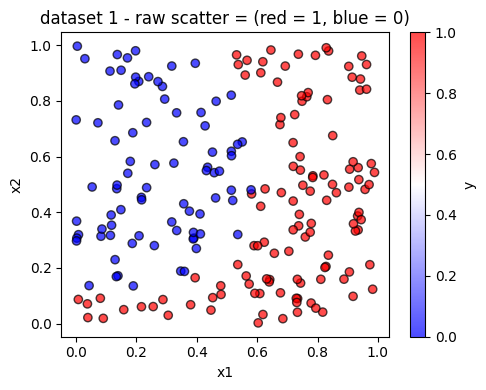

In [6]:
# plotting the dataset's initial position
print("label distribution")
print(df['y'].value_counts()) 

plt.figure(figsize = (5,4))
plt.scatter(df['x1'], df['x2'], c = df['y'], cmap = 'bwr', edgecolors = 'k', alpha = 0.7)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('dataset 1 - raw scatter = (red = 1, blue = 0)')
plt.colorbar(label = 'y')
plt.tight_layout()
plt.show()



Preparing Data (Train-Test Split + Scaling)

In [8]:
# defining the axes
X = df[['x1', 'x2']]
y = df['y']

# train-test split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.3, random_state = 42)
print(f"train size: {X_train.shape[0]} test size: {X_test.shape[0]}")

# standardization of dataset
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

train size: 140 test size: 60


1- K-Nearest Neighbor Analysis on Cleaned Data

In [9]:
results = []  # array for storing results

# design a for loop that enables us to compare the performances of odd k values from 1 to 51
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, knn.predict(X_test_scaled))
    results.append({'k': k, 'accuracy': acc, 'error': 1 - acc})

# we will store the values as a table table format which shows accuracy and error columns for a particular k value
df_baseline = pd.DataFrame(results)
best_baseline = df_baseline.loc[df_baseline['accuracy'].idxmax()]
print(df_baseline.to_string(index = False))

 k  accuracy    error
 1  0.983333 0.016667
 3  0.966667 0.033333
 5  0.950000 0.050000
 7  0.966667 0.033333
 9  0.983333 0.016667
11  0.983333 0.016667
13  0.983333 0.016667
15  0.983333 0.016667
17  0.983333 0.016667
19  0.983333 0.016667
21  0.966667 0.033333
23  0.950000 0.050000
25  0.966667 0.033333
27  0.966667 0.033333
29  0.966667 0.033333
31  0.966667 0.033333
33  0.966667 0.033333
35  0.966667 0.033333
37  0.966667 0.033333
39  0.966667 0.033333
41  0.966667 0.033333
43  0.966667 0.033333
45  0.966667 0.033333
47  0.966667 0.033333
49  0.950000 0.050000
51  0.950000 0.050000


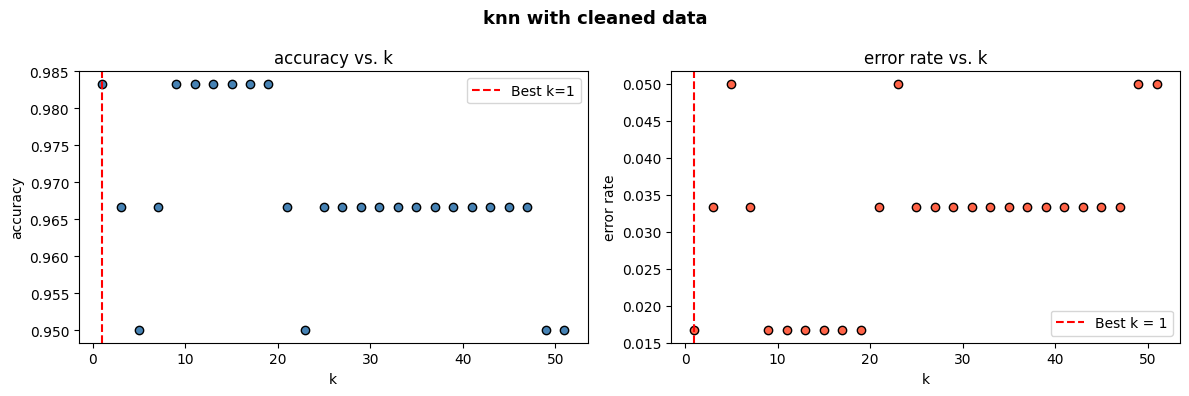

In [10]:
# we can also create comparative graphs that show the change in accuracy and error rate (continue below)
# of algorithm with change in k value, instead of just table representation.

# accuracy vs. k graph
fig, axes = plt.subplots(1,2, figsize = (12,4))

axes[0].scatter(df_baseline['k'], df_baseline['accuracy'], color = 'steelblue', edgecolors = 'k')
axes[0].axvline(best_baseline['k'], color = 'red', linestyle = '--' , label=f"Best k={int(best_baseline['k'])}")
axes[0].set_xlabel('k')
axes[0].set_ylabel('accuracy')
axes[0].set_title('accuracy vs. k')
axes[0].legend()

# error rate vs. k graph
axes[1].scatter(df_baseline['k'], df_baseline['error'], color = 'tomato', edgecolors = 'k')
axes[1].axvline(best_baseline['k'], color = 'red', linestyle = '--', label = f"Best k = {int(best_baseline['k'])}")
axes[1].set_xlabel('k')
axes[1].set_ylabel('error rate')
axes[1].set_title('error rate vs. k')
axes[1].legend()


plt.suptitle('knn with cleaned data', fontsize = 13, fontweight = 'bold')
plt.tight_layout()
plt.show()

1.2 Classification Report for Best K-Value (k=1 in this case )

best k: 1
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        27
           1       0.97      1.00      0.99        33

    accuracy                           0.98        60
   macro avg       0.99      0.98      0.98        60
weighted avg       0.98      0.98      0.98        60



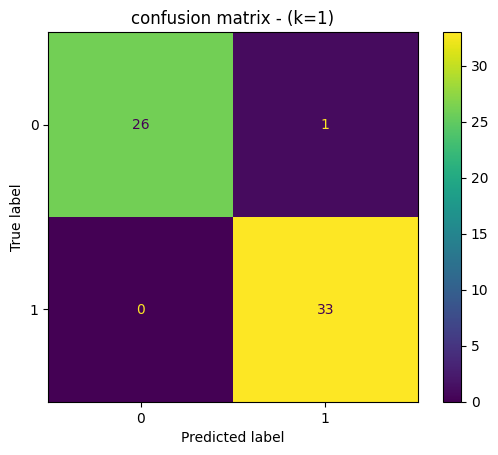

In [11]:
# fit training data to the best k, and predict next y based on test data
best_k = int(best_baseline['k'])
knn_best = KNeighborsClassifier(n_neighbors = best_k)
knn_best.fit(X_train_scaled, y_train)
y_pred = knn_best.predict(X_test_scaled)

# creating precision, recall, f1-score table and confusion matrix for optimal k-value 
print(f"best k: {best_k}")
print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title(f"confusion matrix - (k={best_k})")
plt.show()

2- Analysis with Flipped Training Labels (with %20 probability given by assignment)

In [12]:
np.random.seed(42)

# copy the original training data set and create a new variable for noisy training data
y_train_noisy = y_train.copy()
flip_mask = np.random.rand(len(y_train_noisy)) < 0.2  # from the length of noisy set, flip %20 of the set randomly
y_train_noisy.iloc[flip_mask] = 1 - y_train_noisy.iloc[flip_mask]


2.1 Apply Same Knn Analysis For %20 Flipped Training Dataset to Find Optimal K Value

In [13]:
results_noisy_labels = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train_noisy)
    acc = accuracy_score(y_test, knn.predict(X_test_scaled))
    results_noisy_labels.append({'k': k, 'accuracy': acc, 'error': 1 - acc})

df_noisy_labels = pd.DataFrame(results_noisy_labels)
best_noisy_labels = df_noisy_labels.loc[df_noisy_labels['accuracy'].idxmax()]
print(df_noisy_labels.to_string(index=False))

 k  accuracy    error
 1  0.683333 0.316667
 3  0.833333 0.166667
 5  0.816667 0.183333
 7  0.883333 0.116667
 9  0.950000 0.050000
11  1.000000 0.000000
13  0.966667 0.033333
15  0.966667 0.033333
17  0.950000 0.050000
19  0.950000 0.050000
21  0.966667 0.033333
23  0.966667 0.033333
25  0.966667 0.033333
27  0.966667 0.033333
29  0.966667 0.033333
31  0.966667 0.033333
33  0.966667 0.033333
35  0.933333 0.066667
37  0.933333 0.066667
39  0.916667 0.083333
41  0.916667 0.083333
43  0.916667 0.083333
45  0.900000 0.100000
47  0.900000 0.100000
49  0.883333 0.116667
51  0.900000 0.100000


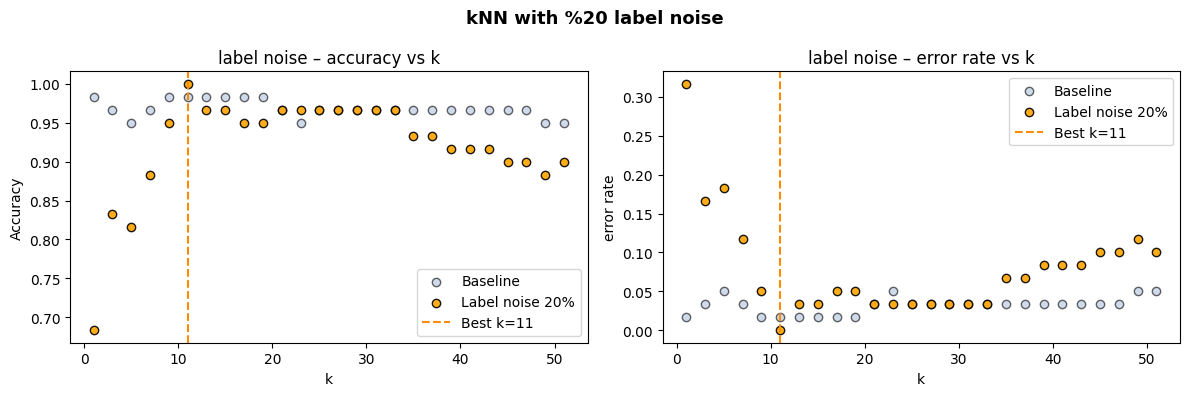

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# label noise & accuracy vs. k graph
axes[0].scatter(df_baseline['k'],      df_baseline['accuracy'],      color='lightsteelblue', edgecolors='k', alpha=0.6, label='Baseline')
axes[0].scatter(df_noisy_labels['k'], df_noisy_labels['accuracy'],  color='orange',         edgecolors='k', alpha=0.9, label='Label noise 20%')
axes[0].axvline(best_noisy_labels['k'], color='darkorange', linestyle='--', label=f"Best k={int(best_noisy_labels['k'])}")
axes[0].set_xlabel('k') 
axes[0].set_ylabel('Accuracy')
axes[0].set_title('label noise – accuracy vs k')
axes[0].legend()

# label noise & error rate vs. k graph 
axes[1].scatter(df_baseline['k'],      df_baseline['error'],      color='lightsteelblue', edgecolors='k', alpha=0.6, label='Baseline')
axes[1].scatter(df_noisy_labels['k'], df_noisy_labels['error'],  color='orange',         edgecolors='k', alpha=0.9, label='Label noise 20%')
axes[1].axvline(best_noisy_labels['k'], color='darkorange', linestyle='--', label=f"Best k={int(best_noisy_labels['k'])}")
axes[1].set_xlabel('k') 
axes[1].set_ylabel('error rate')
axes[1].set_title('label noise – error rate vs k')
axes[1].legend()

plt.suptitle('kNN with %20 label noise', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

2.2 Classification Report for the Best K Value of Noisy Labels 

best k = 1
              precision    recall  f1-score   support

           0       1.00      0.78      0.88        27
           1       0.85      1.00      0.92        33

    accuracy                           0.90        60
   macro avg       0.92      0.89      0.90        60
weighted avg       0.92      0.90      0.90        60



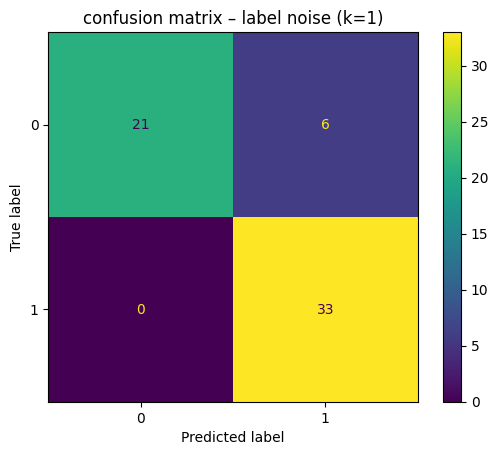

In [15]:
y_pred_nl = knn.predict(X_test_scaled)
print(f"best k = {best_k}")
print(classification_report(y_test, y_pred_nl))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_nl)
plt.title(f'confusion matrix – label noise (k={best_k})')
plt.show()

3.Analysis with 4 Noisy Features (4 random Gaussian features, as they obey normal distribution)

In [17]:
# we should append 4 columns drawn from N(0,1) to both train and test sets, with keeping the labels clean.
np.random.seed(42)

noise_cols = [f'noise_{i}' for i in range (1,5)]
noise = pd.DataFrame(np.random.normal(0,1, size = (len(X), 4)),
                     columns = noise_cols,
                     index = X.index
                     )
X_noisy = pd.concat([X, noise], axis = 1) 
print("shape with noise features: ", X_noisy.shape)
X_noisy.head()


shape with noise features:  (200, 6)


,x1,x2,noise_1,noise_2,noise_3,noise_4
0,0.914806,0.885118,0.496714,-0.138264,0.647689,1.523030
1,0.937075,0.517111,-0.234153,-0.234137,1.579213,0.767435
2,0.286140,0.851931,-0.469474,0.542560,-0.463418,-0.465730
3,0.830448,0.442796,0.241962,-1.913280,-1.724918,-0.562288
4,0.641746,0.157880,-1.012831,0.314247,-0.908024,-1.412304


In [18]:
# train - test split and standard scaling for noisy features
X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(X_noisy, y, test_size=0.3, random_state=42)

sc_n = StandardScaler()
X_train_n_sc = sc_n.fit_transform(X_train_n)
X_test_n_sc = sc_n.transform(X_test_n)

results_noisy_gaussian = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_n_sc, y_train_n)
    acc = accuracy_score(y_test_n, knn.predict(X_test_n_sc))
    results_noisy_gaussian.append({'k':k, 'accuracy': acc, 'error': 1-acc})

df_noisy_feat = pd.DataFrame(results_noisy_gaussian)
best_noisy_feat = df_noisy_feat.loc[df_noisy_feat['accuracy'].idxmax()]
print(df_noisy_feat.to_string(index=False))

 k  accuracy    error
 1  0.800000 0.200000
 3  0.866667 0.133333
 5  0.933333 0.066667
 7  0.900000 0.100000
 9  0.866667 0.133333
11  0.883333 0.116667
13  0.866667 0.133333
15  0.866667 0.133333
17  0.850000 0.150000
19  0.850000 0.150000
21  0.866667 0.133333
23  0.833333 0.166667
25  0.850000 0.150000
27  0.833333 0.166667
29  0.866667 0.133333
31  0.866667 0.133333
33  0.850000 0.150000
35  0.883333 0.116667
37  0.900000 0.100000
39  0.900000 0.100000
41  0.883333 0.116667
43  0.883333 0.116667
45  0.883333 0.116667
47  0.866667 0.133333
49  0.883333 0.116667
51  0.866667 0.133333


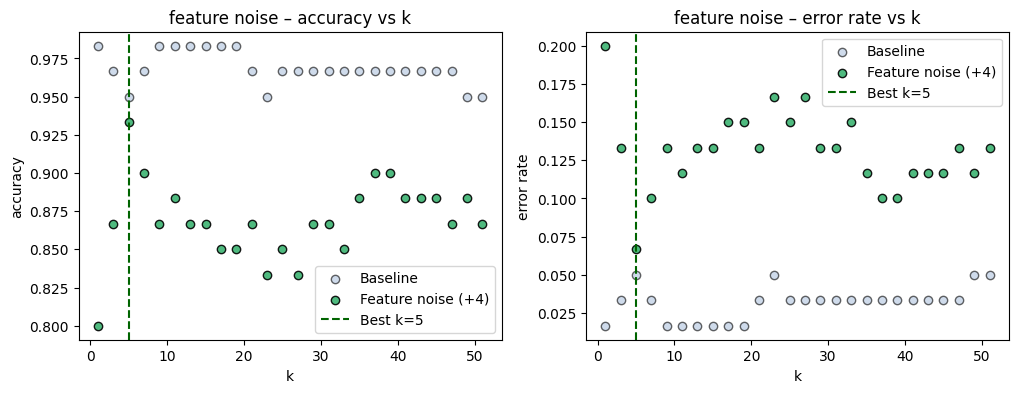

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# feature noise + accuracy vs. k graph
axes[0].scatter(df_baseline['k'],  df_baseline['accuracy'],    color='lightsteelblue', edgecolors='k', alpha=0.6, label='Baseline')
axes[0].scatter(df_noisy_feat['k'], df_noisy_feat['accuracy'], color='mediumseagreen', edgecolors='k', alpha=0.9, label='Feature noise (+4)')
axes[0].axvline(best_noisy_feat['k'], color='darkgreen', linestyle='--', label=f"Best k={int(best_noisy_feat['k'])}")
axes[0].set_xlabel('k'); axes[0].set_ylabel('accuracy')
axes[0].set_title('feature noise – accuracy vs k')
axes[0].legend()

# feature noise + error rate vs. k graph
axes[1].scatter(df_baseline['k'],    df_baseline['error'],    color='lightsteelblue', edgecolors='k', alpha=0.6, label='Baseline')
axes[1].scatter(df_noisy_feat['k'], df_noisy_feat['error'], color='mediumseagreen', edgecolors='k', alpha=0.9, label='Feature noise (+4)')
axes[1].axvline(best_noisy_feat['k'], color='darkgreen', linestyle='--', label=f"Best k={int(best_noisy_feat['k'])}")
axes[1].set_xlabel('k'); axes[1].set_ylabel('error rate')
axes[1].set_title('feature noise – error rate vs k')
axes[1].legend()

Classification Report (Best K Value for Gaussian Noisy Features)

best k = 5
              precision    recall  f1-score   support

           0       1.00      0.85      0.92        27
           1       0.89      1.00      0.94        33

    accuracy                           0.93        60
   macro avg       0.95      0.93      0.93        60
weighted avg       0.94      0.93      0.93        60



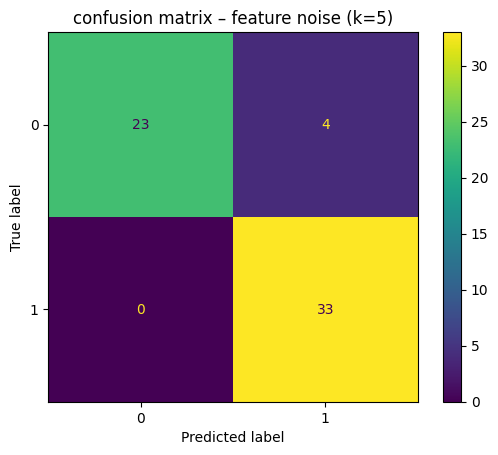

In [20]:
best_k_fn = int(best_noisy_feat['k'])
knn_fn = KNeighborsClassifier(n_neighbors=best_k_fn)
knn_fn.fit(X_train_n_sc, y_train_n)
y_pred_fn = knn_fn.predict(X_test_n_sc)

print(f"best k = {best_k_fn}")
print(classification_report(y_test_n, y_pred_fn))
ConfusionMatrixDisplay.from_predictions(y_test_n, y_pred_fn)
plt.title(f'confusion matrix – feature noise (k={best_k_fn})')
plt.show()
